# Notebook for preprocessing EDGAR8 for use as anthropogenic prior

* select years
* cut domain
* sum sector-specific gridded fluxes together 

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import re
from copy import deepcopy

In [14]:
DATA_PATH1 = "/home/pietaril/Documents/data/CIF/CO2_responsefunction_inversion/priors/EDGAR8/bio_EDGAR"
DATA_PATH2 = "/home/pietaril/Documents/data/CIF/CO2_responsefunction_inversion/priors/EDGAR8/IEA_EDGAR"




def get_filenames(dirpaths):
    filenames = []
    for dirpath in dirpaths:
        for subdir in os.listdir(dirpath):
            subdirpath = os.path.join(dirpath, subdir)
            filenames +=  [os.path.join(subdirpath,f) for f in os.listdir(subdirpath) if f.endswith(".nc")]
    return filenames


def extract_year(filename):
    #Extract year from filename
    year = int(re.findall(r'\d{4}', filename)[1])
    return year

def select_area(aoi, ds):
    # Select the area based on area of interest
    
    area_subset = ds.sel(lon=slice(aoi[0], aoi[1]),
                    lat=slice(aoi[2], aoi[3]))
    return area_subset





def sum_fluxes(aoi, input_files, output_file=None):
    """
    Sums the 'fluxes' variable across multiple NetCDF files and writes the result to a new NetCDF file.

    Parameters:
    - input_files (list of str): List of paths to input NetCDF files.
    - output_file (str): Path to the output NetCDF file.
    """
 

    # Open all input files
    datasets = [xr.open_dataset(file) for file in input_files]
    

    #pick area
    subsets = [select_area(aoi, ds) for ds in datasets]

    # Compute the sum of fluxes across all datasets

    flux_sum = sum(ds for ds in subsets)

    # Save the result to a new NetCDF file
    
    flux_sum.attrs.update({"description": "Sum of gridded EDGAR_2024_GHG CO2 fluxes across all sectors",
                           "units": datasets[0].attrs["units"]})



    # Write the output dataset to a new NetCDF file
    #output_ds.to_netcdf(output_file)

    # Close all datasets
    for ds in datasets:
        ds.close()

    return flux_sum






In [15]:



aoi = [-15, 40, 34, 73]

fnames = get_filenames([DATA_PATH1, DATA_PATH2])


# create DataFrame with filenames and years to later group by year
df_filenames = pd.DataFrame({'filename': fnames})
df_filenames['year'] = df_filenames['filename'].apply(extract_year)
df_filenames = df_filenames.sort_values('year').reset_index(drop=True)

for year in range(2008,2009): #2024):
    files_1year = df_filenames[df_filenames['year']==year]['filename'].to_list()
    assert len(files_1year)==16
    flux_sum = sum_fluxes(aoi, files_1year)
    


In [16]:
flux_sum

<xarray.Dataset>
Dimensions:  (lat: 390, lon: 550, time: 12)
Coordinates:
  * lat      (lat) float64 34.05 34.15 34.25 34.35 ... 72.65 72.75 72.85 72.95
  * lon      (lon) float64 -14.95 -14.85 -14.75 -14.65 ... 39.75 39.85 39.95
  * time     (time) datetime64[ns] 2008-01-15 2008-02-15 ... 2008-12-15
Data variables:
    fluxes   (time, lat, lon) float32 2.036e-10 1.969e-10 ... 2.111e-11
Attributes:
    description:  Sum of gridded EDGAR_2024_GHG CO2 fluxes across all sectors
    units:        kg m-2 s-1

<xarray.DataArray 'fluxes' ()>
array(0.)

In [ ]:

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature



In [60]:
#from datetime import datetime
data = flux_sum["fluxes"]
str(data.time.values[0])[0:7]


'2008-01'

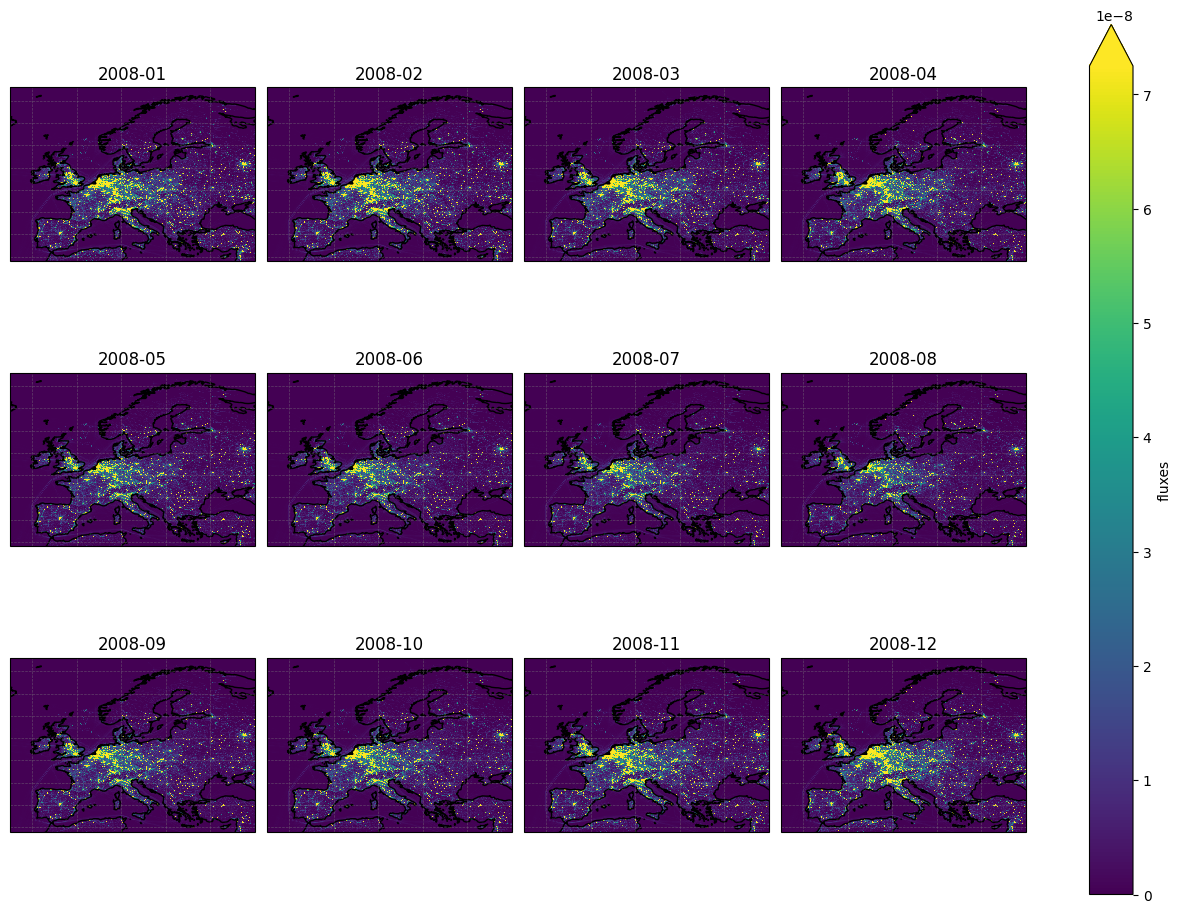

In [76]:
data = flux_sum["fluxes"]
g = data.plot.imshow(x="lon", y="lat", col="time", col_wrap=4, robust=True, 
                     subplot_kws=dict(projection=ccrs.PlateCarree(),),

)


for i, ax in enumerate(g.axes.flat):
    time = str(data.time.values[i])[0:7]
    ax.set_title(time)
    ax.coastlines()
    ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')



plt.draw()

In [47]:
g.axes.flat

In [52]:
datasets[0]

<xarray.Dataset>
Dimensions:  (lat: 1800, lon: 3600, time: 12)
Coordinates:
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.8 179.8 179.9
  * time     (time) datetime64[ns] 2000-01-15 2000-02-15 ... 2000-12-15
Data variables:
    fluxes   (time, lat, lon) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    description:       Fuel exploitation
    institution:       European Commission, Joint Research Centre
    source:            https://edgar.jrc.ec.europa.eu/dataset_ghg2024
    how_to_cite:       https://edgar.jrc.ec.europa.eu/dataset_ghg2024#howtocite
    copyright_notice:  https://edgar.jrc.ec.europa.eu/dataset_ghg2024#conditions
    contacts:          https://edgar.jrc.ec.europa.eu/dataset_ghg2024#info JR...
    units:             kg m-2 s-1

In [48]:
fluxes_sum

<xarray.Dataset>
Dimensions:  (lat: 1800, lon: 3600, time: 12)
Coordinates:
  * lat      (lat) float64 -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon      (lon) float64 -179.9 -179.8 -179.8 -179.7 ... 179.8 179.8 179.9
  * time     (time) datetime64[ns] 2000-01-15 2000-02-15 ... 2000-12-15
Data variables:
    fluxes   (time, lat, lon) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [30]:
da2 = xr.open_dataarray(files_1year["filename"][1])

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (12, 1800, 3600) and arg 1 with shape (0,).